<a id="top"></a>

# Teach Open Biocatalysis

## RDM-01a: EnzymeML and Research Data Management

> **You are here:** this is the **research-data-management module** of the *Teach Open Biocatalysis* series. It takes the processed dataset from WET-01a and turns it into a standardised, machine-readable **EnzymeML** document that downstream tools (and module KIN-01a) can consume directly.

---

### Course Goal

*Teach Open Biocatalysis* provides accessible, open-source educational materials that bridge classical enzyme kinetics(Reaction Speed) with modern data management (FAIR) and computational modeling. In this module you will:

- Understand why FAIR data principles matter for biocatalysis
- Get to know **EnzymeML** as a community standard for enzyme-kinetic data
- Build an EnzymeML document **programmatically with PyEnzyme**
- Get pointers to the **EnzymeML Suite** desktop GUI as an alternative entry point
- Export a FAIR-compliant document that KIN-01a can load directly

---

### Where this notebook fits in the workflow

```mermaid
flowchart LR
    A[WET-01a<br/>Wet-lab assay<br/>and data acquisition] --> B[RDM-01a<br/>EnzymeML and<br/>FAIR data management]
    B --> C[KIN-01a<br/>Kinetic modeling<br/>and parameter fitting]
    style A fill:#e5e7eb,stroke:#374151,color:#111
    style B fill:#fde68a,stroke:#b45309,stroke-width:2px,color:#111
    style C fill:#e5e7eb,stroke:#374151,color:#111
```

> If the diagram above does not render in your environment, the workflow is simply: **WET-01a → RDM-01a → KIN-01a**.

---

### Table of Contents

- [0. Setup](#sec-setup)
- [Part 1 — FAIR Data in Biocatalysis](#sec-part1)
  - [1.1 The FAIR principles in one page](#sec-1-1)
  - [1.2 STRENDA guidelines (further reading)](#sec-1-2)
- [Part 2 — EnzymeML: the community standard](#sec-part2)
  - [2.1 What is EnzymeML?](#sec-2-1)
  - [2.2 Anatomy of an EnzymeML document](#sec-2-2)
- [Part 3 — Tooling: PyEnzyme & EnzymeML Suite](#sec-part3)
  - [3.1 PyEnzyme (Python library)](#sec-3-1)
  - [3.2 EnzymeML Suite (desktop GUI)](#sec-3-2)
- [Part 4 — Building the EnzymeML document with PyEnzyme](#sec-part4)
  - [4.1 Define enzyme, reaction and species](#sec-4-1)
  - [4.2 Load the processed dataset from WET-01a](#sec-4-2)
  - [4.3 Add measurements](#sec-4-3)
  - [4.4 Export and inspect](#sec-4-4)
- [Part 5 — Visualisation and Quality Check](#sec-part5)
- [Conclusion & Outlook](#sec-outlook)
- [References & Resources](#sec-references)
- [Acknowledgments](#sec-ack)

---

### Authors & Contributors

- **Niklas-Maximilian Epping**, Institute of Technical Biocatalysis, Hamburg University of Technology — niklas.epping@tuhh.de
- **Andreas Liese**, Institute of Technical Biocatalysis, Hamburg University of Technology — liese@tuhh.de
- **Shakir Ansari**, Institute of Technical Biocatalysis, Hamburg University of Technology - shakir.ansari@tuhh.de

Built on the EnzymeML community standard and the PyEnzyme library developed by the group of **Prof. Jürgen Pleiss** at the University of Stuttgart. See the [Acknowledgments](#sec-ack) for details.

---

### What you will do in this notebook

| Step | What you do | Why it matters |
|------|-------------|----------------|
| 1 | Read short primers on FAIR, STRENDA and EnzymeML | Understand the context |
| 2 | Fetch the FDH reaction from Rhea and the enzyme from UniProt | Get ontology-linked metadata for free |
| 3 | Load the processed CSV from WET-01a | Re-use your own (or the reference) wet-lab data |
| 4 | Add 36 measurements to an EnzymeML document | Structure the data with PyEnzyme |
| 5 | Export to EnzymeML / JSON | Hand off a FAIR document to KIN-01a |

> **No wet-lab data yet?** WET-01a falls back automatically to the reference dataset `Data/examples/data_initialrate.csv`. The processed file `Data/processed/FDH_kinetic_data_calculated.csv` is therefore always available, and this notebook will work end-to-end either way.


<a id="sec-part1"></a>

# Part 1 — FAIR Data in Biocatalysis

<a id="sec-1-1"></a>

## 1.1 The FAIR principles in one page

The **FAIR principles** (Wilkinson et al., 2016) describe what good research data should look like — independent of any specific format or tool.

Enzyme kinetics:Is reaction speed where Experimental results strongly depend on parameters such as buffer composition, substrate concentration, temperature, pH, and reaction conditions. Therefore, the data must be documented in a way that allows both researchers and computer systems to understand, access, and reproduce the experiment in the future. 

For example, when applying the FAIR principles to enzyme kinetics -> A colleague — or a machine — should be able to pick up your dataset years from now and re-run the analysis without emailing you for e. g. missing details on which buffer and concentrations were used..

<div style="border:2px solid #00d4ff; padding:15px; border-radius:10px; background-color:#1e1e1e; color:#eaeaea;">
In the WET-01a module you already produced FAIR-friendly artefacts:

- a tabular CSV (`Data/processed/FDH_kinetic_data_calculated.csv`)
- a STRENDA-style metadata dictionary (`meta_data` in WET-01a)
- ontology references (UniProt `O13437`, Rhea `15985`)

What is still missing is a single, structured file that bundles **all** of this together in a machine-readable form. That file is the **EnzymeML document** built later in this notebook.
</div>

<a id="sec-1-2"></a>

## 1.2 STRENDA guidelines (further reading)

The **STRENDA Biocatalysis guidelines** (*Standards for Reporting Enzymology Data*, Beilstein-Institut) define the *minimum information* that should accompany any enzyme-kinetic measurement so that the result can be reproduced and reused — enzyme identity and source, assay conditions (buffer, pH, T, ionic strength), substrate identities (ChEBI / SMILES / InChI), enzyme concentration, detection method, replicates, statistics, and so on. [Similar to identifying which software, library, or system version is being executed]

We deliberately do **not** treat STRENDA as a separate module here. Instead, **EnzymeML implements the STRENDA recommendations as a concrete, machine-readable data structure**, so by building an EnzymeML document in this notebook you are automatically following STRENDA in practice.

If you would like to read up on the underlying recommendations themselves, the most relevant sources are:

- STRENDA homepage (Beilstein-Institut): <https://www.beilstein-institut.de/en/projects/strenda/>
- STRENDA Biocatalysis guidelines: <https://github.com/Strenda-biocatalysis/Strenda-biocatalysis>
- STRENDA DB (public submission portal): <https://www.beilstein-strenda-db.org/>

For the rest of this notebook we focus on **EnzymeML** as the actual implementation.

[Back to top](#top)


---

<a id="sec-part2"></a>

# Part 2 — EnzymeML: the community standard

<a id="sec-2-1"></a>

## 2.1 What is EnzymeML?

> *"EnzymeML is a standardized data format for catalytic reaction data, designed to ensure consistency and interoperability. It enables researchers to store, share, and enrich reaction data with detailed metadata in JSON or XML formats."* — [enzymeml.org](https://enzymeml.org/)

In short, EnzymeML is a standardized file format used to store enzyme experiment data together with all important metadata in a structured and machine-readable way.

And EnzymeML is the answer to a deceptively simple question:

> *"If I want to share an enzyme-kinetic experiment with a colleague, a database, or a fitting tool — what should the file look like?"*

Key properties:

- **One document = one biocatalytic experiment** (or campaign), with proteins, small molecules, vessels, reactions, conditions, and time-course measurements all in one place.
- **Built on community standards.** EnzymeML is an SBML-compatible exchange format, with first-class hooks to **UniProt** (proteins), **ChEBI / PubChem** (small molecules), **Rhea** (reactions), and **PDB** (structures).
- **Two serialisation flavours.** You can read and write EnzymeML as **JSON** (recommended for new work) or **XML/SBML** (for compatibility with COPASI, PySCeS, CellDesigner, …).
- **Tool ecosystem.** PyEnzyme (Python), the EnzymeML Suite (desktop GUI) and the EnzymeML TypeScript API all consume and produce the *same* document, so you can move between bench, code and modeling without manual re-formatting.

<a id="bio-databases-tools"></a>
For Information sake:
> **UniProt** → database for protein and enzyme information.  
> **ChEBI / PubChem** → databases for chemical molecules and compounds.  
> **Rhea** → database of standardized biochemical reactions.  
> **PDB** → database containing 3D protein structures.  
> **SBML** → standard format for storing and exchanging biological models.  
> **PyEnzyme** → Python library used to create and work with EnzymeML documents.  
> **EnzymeML Suite** → desktop software for viewing and editing EnzymeML experiments.  
> **COPASI** → software used for simulating and analyzing biochemical reaction networks and enzyme kinetics models.  
> **PySCeS** → a Python-based tool used for mathematical modeling and simulation of biochemical systems.  
> **Bayesian inference** → a statistical method that updates predictions or probabilities as new experimental data becomes available.  
> **Neural-ODE modeling** → a machine learning approach that combines neural networks with differential equations to model dynamic systems over time.  
> **Protein metadata** → structured information describing the enzyme, such as name, sequence, organism, and identifiers.  
> **SMILES** → a text-based format used to represent chemical molecule structures.  
> **ChEBI IDs** → standardized database identifiers for chemical compounds and molecules.  
> **Stoichiometry** → the quantitative relationship showing how many molecules are consumed and produced in a reaction.  
> **TypeScript API** → programming interface for using EnzymeML in web and software applications.

> These databases, formats, and tools work like connected APIs, libraries, schemas, simulation frameworks, and standardized data services used for storing, exchanging, processing, and modeling biological experiment data.
### Why use EnzymeML rather than just a CSV?

A CSV captures *numbers*. An EnzymeML document captures *numbers in context*: which enzyme variant, which assay conditions, which species each column refers to, which ontology IDs the species correspond to, what units and what time base apply. That context is what makes the data interoperable and reusable as well as explainable and AI-ready — and what allows the KIN-01a module to load the data and start fitting without any further hand-holding.

<a id="sec-2-2"></a>

## 2.2 Anatomy of an EnzymeML document

An EnzymeML document (v2) is organised around four core elements, plus a `Vessel` describing the reactor:

```
EnzymeMLDocument
├── Vessels            # reaction container (e.g. 1 mL cuvette)
├── Proteins           # enzyme(s) – linked to UniProt, with sequence, EC, organism
├── SmallMolecules     # substrates, products, cofactors, inhibitors
│                       # linked to ChEBI / PubChem, with SMILES / InChI
├── Reactions          # stoichiometry + reversibility; linked to Rhea
└── Measurements       # the actual experiments:
                       #   - conditions (T, pH, …)
                       #   - per-species time courses
                       #   - replicate structure
```

For our FDH assay this maps cleanly to the columns of `FDH_kinetic_data_calculated.csv`:

| EnzymeML element | What it holds for this experiment |
|------------------|-----------------------------------|
| Protein           | FDH1 from *Candida boidinii*, UniProt `O13437` |
| Small Molecules   | NAD⁺, NADH, formate (HCOO⁻), CO₂ — fetched from Rhea / ChEBI |
| Reaction          | `HCOO⁻ + NAD⁺ → CO₂ + NADH`, Rhea `15985` |
| Measurement (×36) | 36 cuvettes with initial concentrations and the two-point (0 s / 60 s) time course of each species |

[Biological databases and tools](#bio-databases-tools)

The full data-model specification is available at <https://enzymeml.org/versions/v2/>.

[Back to top](#top)


---

<a id="sec-part3"></a>

# Part 3 — Tooling: PyEnzyme & EnzymeML Suite

There are two officially supported ways to author an EnzymeML document — they are fully interchangeable because they produce the same JSON/XML file:

1. **Programmatically**, with **PyEnzyme** (the route used in this notebook). 
>The Python library used to create, read, edit, and process EnzymeML documents programmatically.

2. **Interactively**, with the **EnzymeML Suite** desktop GUI.
>A standardized machine-readable format used to store enzyme experiment data together with metadata in a structured and reusable way

Interrelation Between PyEnzyme and EnzymeML:

>EnzymeML defines the data format, while PyEnzyme is the software library used to work with that format in Python.

<a id="sec-3-1"></a>

## 3.1 PyEnzyme (Python library)

[PyEnzyme](https://github.com/EnzymeML/PyEnzyme) is *the* Python interface to the EnzymeML data model. It offers:

- A pydantic-based object model that mirrors the EnzymeML v2 specification one-to-one.
- Convenience fetchers that pull metadata directly from **UniProt**, **ChEBI**, **PubChem**, **Rhea** and **PDB**, so you do not retype identifiers, names, sequences or SMILES.
- Built-in readers/writers for EnzymeML JSON and SBML (`.omex`).
- Optional plugins for modeling backends (COPASI, PySCeS).

[Biological databases and tools](#bio-databases-tools)

**Installation** (already done if you set the project up with the bundled `requirements.txt`):

```bash
python -m pip install pyenzyme
```

**Minimal usage pattern** (we will expand on this below):

```python
import pyenzyme as pe

# Fetch from databases instead of typing things by hand
protein               = pe.fetch_uniprot("O13437")
reaction, molecules   = pe.fetch_rhea("RHEA:15985")

# Build the document
doc = pe.EnzymeMLDocument(
    name="FDH kinetic assay",
    proteins=[protein],
    reactions=[reaction],
    small_molecules=molecules,
)

# … add measurements …

pe.write_enzymeml(doc, "FDH_kinetics.json")
```

PyEnzyme also offers a one-liner `pe.compose(...)` for fully-database-driven document creation, see the [README](https://github.com/EnzymeML/PyEnzyme).

<a id="sec-3-2"></a>

## 3.2 EnzymeML Suite (desktop GUI)

If you prefer a point-and-click workflow, the **EnzymeML Suite** is the official graphical front-end:

>The EnzymeML Suite is a user-friendly desktop application that helps researchers create, validate, analyze, and model enzyme experiment data without needing extensive coding.

- Cross-platform desktop app (Windows, macOS, Linux), built with Tauri + React.
- Forms-based entry of proteins, small molecules, vessels, reactions and measurements with on-the-fly validation against the EnzymeML schema.
- Built-in Jupyter integration with templates for basic analysis, COPASI, PySCeS, Bayesian inference, neural-ODE modeling, etc.
- AI-assisted extraction of kinetic parameters from free text.

[Biological databases and tools](#bio-databases-tools)

**Download / source code:** <https://github.com/EnzymeML/enzymeml-suite>
**Releases (installers):** <https://github.com/EnzymeML/enzymeml-suite/releases>

Both routes produce *the same kind of file*. You can perfectly well draft a document in the Suite, save it as JSON, and continue working with it from PyEnzyme — and vice versa. For teaching we use PyEnzyme below because it makes every step explicit and version-controllable.

[Back to top](#top)


In [1]:
# Path setup and data directory management
from pathlib import Path

# Project layout (this notebook lives in Notebooks/)
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
EXAMPLES_DIR = DATA_DIR / "examples"
ENZYMEML_DIR = DATA_DIR / "enzymeml"

# Make sure all directories exist
for directory in [RAW_DATA_DIR, PROCESSED_DATA_DIR, EXAMPLES_DIR, ENZYMEML_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Locate the dataset produced by WET-01a
DATA_FILE = PROCESSED_DATA_DIR / "FDH_kinetic_data_calculated.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"  Processed input  <- {PROCESSED_DATA_DIR}")
print(f"  EnzymeML output  -> {ENZYMEML_DIR}\n")

if DATA_FILE.exists():
    print(f"Found WET-01a output: {DATA_FILE.relative_to(PROJECT_ROOT)}")
else:
    print("WARNING: WET-01a output not found.")
    print("  Please run WET-01a first. It auto-falls back to the reference")
    print("  dataset, so a processed CSV is produced either way.")


Project root: /Users/niklas-maximilianepping/Projekte/TeachOpenBiocatalysis/Export/TeachOpenBiocatalysis_WET-RDM
  Processed input  <- /Users/niklas-maximilianepping/Projekte/TeachOpenBiocatalysis/Export/TeachOpenBiocatalysis_WET-RDM/Data/processed
  EnzymeML output  -> /Users/niklas-maximilianepping/Projekte/TeachOpenBiocatalysis/Export/TeachOpenBiocatalysis_WET-RDM/Data/enzymeml

Found WET-01a output: Data/processed/FDH_kinetic_data_calculated.csv


<a id="sec-setup"></a>

## 0. Setup

The cell above prepares the Python paths so the notebook can pick up the processed CSV produced by WET-01a (`Data/processed/FDH_kinetic_data_calculated.csv`) and write the resulting EnzymeML documents into `Data/enzymeml/`. Run it once at the beginning of the session.

[Back to top](#top)


---

<a id="sec-part4"></a>

# Part 4 — Building the EnzymeML document with PyEnzyme

This is the hands-on part. We now turn the processed CSV from WET-01a into a complete EnzymeML document. The workflow has four small steps:

1. **Define enzyme, reaction and species** — fetched from UniProt and Rhea so we do not retype identifiers, sequences or stoichiometry.
2. **Load the processed dataset** from WET-01a.
3. **Add 36 measurements** to the document, each with its initial conditions and a two-point (0 s / 60 s) time course per species.
4. **Export and inspect** — write JSON to `Data/enzymeml/` and run a quick sanity check on one measurement.

By the end of Part 4 you will have a single, FAIR-compliant file that KIN-01a can load directly.


In [2]:
# Required libraries
import json
from datetime import datetime
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyenzyme as pe

warnings.filterwarnings("ignore")
print(f"PyEnzyme version: {pe.__version__ if hasattr(pe, '__version__') else 'installed'}")


PyEnzyme version: 2.2.0


<a id="sec-4-1"></a>

## 4.1 Define enzyme, reaction and species

Instead of typing protein metadata, SMILES, ChEBI IDs or stoichiometry by hand, we let PyEnzyme **fetch them directly from UniProt and Rhea**. Two lines of code give us a fully annotated enzyme and reaction — including all participating small molecules.

- `pe.fetch_uniprot("O13437")` → FDH1 from *Candida boidinii*, with sequence, EC number, organism and taxonomy.
- `pe.fetch_rhea("RHEA:15985")` → the FDH reaction with stoichiometry, plus all participating ChEBI-annotated small molecules (NAD⁺, NADH, formate, CO₂, H⁺).

We then bundle everything into an `EnzymeMLDocument`.

[Biological databases and tools](#bio-databases-tools)


In [3]:
# 1) Fetch the FDH reaction (and all involved small molecules) from Rhea
reaction, molecules = pe.fetch_rhea("RHEA:15985")

# 2) Define the enzyme. For a teaching example we use a minimal Protein object
#    referencing the UniProt accession used throughout the series (FDH1 from
#    Candida boidinii). For a fully fetched record you could alternatively use:
#        protein = pe.fetch_uniprot("O13437")
protein = pe.Protein(
    id="FDH1",
    name="Formate dehydrogenase 1 (FDH1) from Candida boidinii",
    sequence=None,            # populated automatically when using fetch_uniprot
    ecnumber="1.17.1.9",
    organism="Candida boidinii",
)

# 3) Build the EnzymeML document
doc = pe.EnzymeMLDocument(
    name="FDH kinetic assay (WET-01a)",
    proteins=[protein],
    reactions=[reaction],
    small_molecules=molecules,
)

print("EnzymeML document initialised.")
print(f"  Proteins         : {len(doc.proteins)}")
print(f"  Reactions        : {len(doc.reactions)}")
print(f"  Small molecules  : {len(doc.small_molecules)}")
print("\nSmall-molecule IDs fetched from Rhea:")
for mol in doc.small_molecules:
    print(f"  - {mol.id:<18} {mol.name}")


EnzymeML document initialised.
  Proteins         : 1
  Reactions        : 1
  Small molecules  : 4

Small-molecule IDs fetched from Rhea:
  - formate            formate
  - nad_1              NAD(1-)
  - carbon_dioxide     carbon dioxide
  - nadh_2             NADH(2-)


<a id="sec-4-2"></a>

## 4.2 Load the processed dataset from WET-01a

In this step, we load and verify the processed experimental dataset from WET-01a, which already contains calculated concentrations, reaction rates, and enzyme activity values needed to build the EnzymeML document; it applied the Lambert–Beer law, computed concentrations at *t* = 0 s and *t* = 60 s for every species, and stored the result as `Data/processed/FDH_kinetic_data_calculated.csv`. We now load it and inspect the columns we will need below.


In [4]:
# Load the processed dataset from WET-01a
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Expected WET-01a output not found at {DATA_FILE}.\n"
        "Please run WET-01a first — it produces this file (it also has a "
        "fallback to the bundled reference dataset, so a CSV is always created)."
    )

df = pd.read_csv(DATA_FILE)
print(f"Loaded {DATA_FILE.relative_to(PROJECT_ROOT)}")
print(f"  Shape: {df.shape[0]} measurements x {df.shape[1]} columns\n")
print("Columns:")
for col in df.columns:
    print(f"  - {col}")

print("\nPreview (first 3 rows):")
display(df.head(3))


Loaded Data/processed/FDH_kinetic_data_calculated.csv
  Shape: 36 measurements x 16 columns

Columns:
  - ID
  - FDH_0
  - NAD_0
  - HCOO_0
  - NADH_0
  - CO2_0
  - initial_rate
  - Abs_0s
  - Abs_60s
  - dA_60s
  - dNADH_mM
  - NADH_60
  - NAD_60
  - HCOO_60
  - CO2_60
  - specific_activity_U_per_mg

Preview (first 3 rows):


,ID,FDH_0,NAD_0,HCOO_0,NADH_0,CO2_0,initial_rate,Abs_0s,Abs_60s,dA_60s,dNADH_mM,NADH_60,NAD_60,HCOO_60,CO2_60,specific_activity_U_per_mg
0,1,0.04,0.649196,0.0,0.0,0.0,0.0005,0.0,0.0005,0.0005,0.000080,0.000080,0.649116,-0.000080,0.000080,0.002010
1,2,0.04,0.649196,5.0,0.0,0.0,0.0067,0.0,0.0067,0.0067,0.001077,0.001077,0.648119,4.998923,0.001077,0.026929
2,3,0.04,0.649196,10.0,0.0,0.0,0.0142,0.0,0.0142,0.0142,0.002283,0.002283,0.646913,9.997717,0.002283,0.057074


<div style="border:2px solid #00d4ff; padding:15px; border-radius:10px; background-color:#1e1e1e; color:#eaeaea;">

This result is the cleaned and calculated version of the experimental data, ready for EnzymeML export, computational modeling, and further data analysis workflows.

</div>

<a id="sec-4-3"></a>

## 4.3 Add measurements

<b>Simple Overview</b>
>In this step, each row from the CSV dataset is converted into a structured EnzymeML measurement object containing experiment settings, molecule concentrations, and reaction values over time.
The system also maps the dataset columns to the correct molecule IDs so the data becomes standardized and machine-readable.

Each row of the CSV is one cuvette / one kinetic assay and becomes one `Measurement` in the EnzymeML document. For each measurement we add:

- the experimental conditions (temperature and pH from the WET-01a metadata),
- one `species_data` entry per chemical species (NAD⁺, formate, NADH, CO₂), each containing
  - the initial concentration at *t* = 0 s,
  - the two-point time course `[t=0 s, t=60 s]`,
  - the time and concentration units (`s` and `mmol/l`).

The only fiddly bit is wiring the CSV column names (`NAD_0`, `NAD_60`, …) to the species IDs that Rhea returned (e.g. `nad`, `formate`, `nadh`, `carbon_dioxide`). We do this with a small dictionary you can adapt if Rhea returns different IDs in the future.


In [5]:
# Inspect the species IDs Rhea returned, so we can map CSV columns to them
print("Species currently in the EnzymeML document:")
print("-" * 60)
for mol in doc.small_molecules:
    print(f"  ID: {mol.id:<18}  Name: {mol.name}")
print("-" * 60)

# Map CSV columns (t=0 / t=60) to EnzymeML small-molecule IDs.
# Adjust the right-hand side if Rhea returns different IDs in your version.
species_mapping = {
    "nad_1":          ("NAD_0",  "NAD_60"),    # NAD+         (substrate)
    "formate":        ("HCOO_0", "HCOO_60"),   # Formate      (substrate)
    "nadh_2":         ("NADH_0", "NADH_60"),   # NADH         (product)
    "carbon_dioxide": ("CO2_0",  "CO2_60"),    # CO2          (product)
}

# Sanity-check the mapping against what is actually in the document
known_ids = {mol.id for mol in doc.small_molecules}
unmapped  = [sid for sid in species_mapping if sid not in known_ids]
if unmapped:
    print(f"\nWARNING: these species IDs were not returned by Rhea: {unmapped}")
    print("        Update `species_mapping` to match the IDs printed above.")
else:
    print(f"\nMapping OK: {len(species_mapping)} species linked to CSV columns.")


Species currently in the EnzymeML document:
------------------------------------------------------------
  ID: formate             Name: formate
  ID: nad_1               Name: NAD(1-)
  ID: carbon_dioxide      Name: carbon dioxide
  ID: nadh_2              Name: NADH(2-)
------------------------------------------------------------

Mapping OK: 4 species linked to CSV columns.


>The system checks whether the molecule IDs from the CSV dataset correctly match the molecule IDs inside the EnzymeML document.
After verification, the experiment species (NAD⁺, NADH, formate, and CO₂) are successfully linked to the dataset columns for structured EnzymeML integration.

In [6]:
# Add one Measurement per CSV row to the EnzymeML document
TEMPERATURE_C = 22.0    # from meta_data in WET-01a
PH            = 8.0     # from meta_data in WET-01a
TIME_POINTS   = [0, 60] # seconds

n_meas = 0
n_data = 0

for idx, row in df.iterrows():
    measurement = doc.add_to_measurements(
        id=f"measurement_{idx}",
        name=f"FDH_assay_{idx:02d}",
        temperature=TEMPERATURE_C,
        ph=PH,
    )
    n_meas += 1

    for species_id, (col_t0, col_t60) in species_mapping.items():
        if col_t0 not in df.columns or col_t60 not in df.columns:
            continue
        c0  = float(row[col_t0])  if pd.notna(row[col_t0])  else 0.0
        c60 = float(row[col_t60]) if pd.notna(row[col_t60]) else 0.0

        measurement.add_to_species_data(
            species_id=species_id,
            initial=c0,
            data=[c0, c60],
            time=TIME_POINTS,
            time_unit="s",
            data_unit="mmol/l",
        )
        n_data += 1

print(f"Added {n_meas} measurements with {n_data} species-data entries.")
print(f"  (= {n_data / n_meas:.1f} species tracked per measurement)\n")
print("EnzymeML document now contains:")
print(f"  Proteins         : {len(doc.proteins)}")
print(f"  Small molecules  : {len(doc.small_molecules)}")
print(f"  Reactions        : {len(doc.reactions)}")
print(f"  Measurements     : {len(doc.measurements)}")


Added 36 measurements with 144 species-data entries.
  (= 4.0 species tracked per measurement)

EnzymeML document now contains:
  Proteins         : 1
  Small molecules  : 4
  Reactions        : 1
  Measurements     : 36


<a id="sec-4-4"></a>

## 4.4 Export and inspect

We now write the document to disk in two places:

- a **timestamped** snapshot for the lab record (`FDH_kinetics_YYYYMMDD_HHMMSS.json`),
- a **`FDH_kinetics_latest.json`** alias that KIN-01a always loads.

We use `pe.write_enzymeml(...)` (the canonical PyEnzyme serialiser) and a JSON dump for human inspection in your editor or `jq`.


In [7]:
# Serialise the EnzymeML document
timestamp           = datetime.now().strftime("%Y%m%d_%H%M%S")
snapshot_path       = ENZYMEML_DIR / f"FDH_kinetics_{timestamp}.json"
latest_path         = ENZYMEML_DIR / "FDH_kinetics_latest.json"

# PyEnzyme's canonical writer
try:
    pe.write_enzymeml(doc, str(snapshot_path))
    pe.write_enzymeml(doc, str(latest_path))
    writer = "pe.write_enzymeml"
except AttributeError:
    # Fallback for older PyEnzyme builds: dump the pydantic model directly
    for p in (snapshot_path, latest_path):
        with open(p, "w") as f:
            json.dump(doc.model_dump(mode="json"), f, indent=2)
    writer = "doc.model_dump (fallback)"

size_kb = snapshot_path.stat().st_size / 1024
print(f"EnzymeML document written via {writer}:")
print(f"  snapshot : {snapshot_path.relative_to(PROJECT_ROOT)} ({size_kb:.1f} KB)")
print(f"  latest   : {latest_path.relative_to(PROJECT_ROOT)}")
print(f"\nKIN-01a will load `{latest_path.name}` by default.")


EnzymeML document written to 
/Users/niklas-maximilianepping/Projekte/TeachOpenBiocatalysis/Export/TeachOpenBiocatalysis_WET-RDM/Data/enzymeml/FD
H_kinetics_20260527_120326.json

EnzymeML document written to 
/Users/niklas-maximilianepping/Projekte/TeachOpenBiocatalysis/Export/TeachOpenBiocatalysis_WET-RDM/Data/enzymeml/FD
H_kinetics_latest.json

EnzymeML document written via pe.write_enzymeml:
  snapshot : Data/enzymeml/FDH_kinetics_20260527_120326.json (231.1 KB)
  latest   : Data/enzymeml/FDH_kinetics_latest.json

KIN-01a will load `FDH_kinetics_latest.json` by default.


### Sanity check on a single measurement

Before we move on to visualisation, let us look at one measurement in detail and cross-check the numbers against the original CSV. This is the kind of quality check you should run on every freshly built EnzymeML document.


In [8]:
# Inspect measurement 0 in detail
if not doc.measurements:
    raise RuntimeError("No measurements in document — re-run section 4.3.")

sample = doc.measurements[0]
print(f"Measurement details ({sample.id}):")
print(f"  Name        : {sample.name}")
print(f"  Temperature : {sample.temperature} C")
print(f"  pH          : {sample.ph}")
print(f"  Species     : {len(sample.species_data)}\n")

print("Species time courses:")
print("-" * 72)
for sd in sample.species_data:
    if sd.data and sd.time:
        tc = "  ".join(f"t={t}s -> {c:.6f} mM" for t, c in zip(sd.time, sd.data))
        print(f"  {sd.species_id:<18} initial={sd.initial:.6f} mM   {tc}")
print("-" * 72)

# Cross-check against the source CSV (row 0)
row0 = df.iloc[0]
print("\nCross-check vs CSV row 0:")
print(f"  NAD+   {row0['NAD_0']:.6f} -> {row0['NAD_60']:.6f} mM")
print(f"  HCOO-  {row0['HCOO_0']:.6f} -> {row0['HCOO_60']:.6f} mM")
print(f"  NADH   {row0['NADH_0']:.6f} -> {row0['NADH_60']:.6f} mM")
print(f"  CO2    {row0.get('CO2_0', 0.0):.6f} -> {row0['CO2_60']:.6f} mM")


Measurement details (measurement_0):
  Name        : FDH_assay_00
  Temperature : 22.0 C
  pH          : 8.0
  Species     : 4

Species time courses:
------------------------------------------------------------------------
  nad_1              initial=0.649196 mM   t=0.0s -> 0.649196 mM  t=60.0s -> 0.649116 mM
  formate            initial=0.000000 mM   t=0.0s -> 0.000000 mM  t=60.0s -> -0.000080 mM
  nadh_2             initial=0.000000 mM   t=0.0s -> 0.000000 mM  t=60.0s -> 0.000080 mM
  carbon_dioxide     initial=0.000000 mM   t=0.0s -> 0.000000 mM  t=60.0s -> 0.000080 mM
------------------------------------------------------------------------

Cross-check vs CSV row 0:
  NAD+   0.649196 -> 0.649116 mM
  HCOO-  0.000000 -> -0.000080 mM
  NADH   0.000000 -> 0.000080 mM
  CO2    0.000000 -> 0.000080 mM


<div style="border:2px solid #00d4ff; padding:15px; border-radius:10px; background-color:#1e1e1e; color:#eaeaea;">



In this step, the complete EnzymeML experiment document is exported and saved as structured JSON files for reuse, sharing, and downstream computational workflows. The result confirms that the enzyme experiment, metadata, reactions, and measurements were successfully converted into a machine-readable EnzymeML document that can now be loaded directly by other modeling modules and software tools.

CS analogy:

> Similar to exporting a fully processed project dataset into a standardized JSON file for analytics, simulation, or machine learning pipelines.

</div>

[Back to top](#top)

---

<a id="sec-part5"></a>

# Part 5 — Visualisation and Quality Check

A FAIR document is only useful if the numbers inside it are right. As a final step we plot the time courses **directly out of the EnzymeML document** (not out of the CSV) to confirm that everything was wired up correctly and that the expected behaviour — substrate consumption (NAD⁺, formate) and product formation (NADH, CO₂) — is visible.

We produce three views:

1. A 6 × 6 panel with one subplot per measurement (good for spotting outliers).
2. A combined overlay of *all* measurements per species.
3. A focused view on NAD⁺ and NADH only, with a small statistical summary.


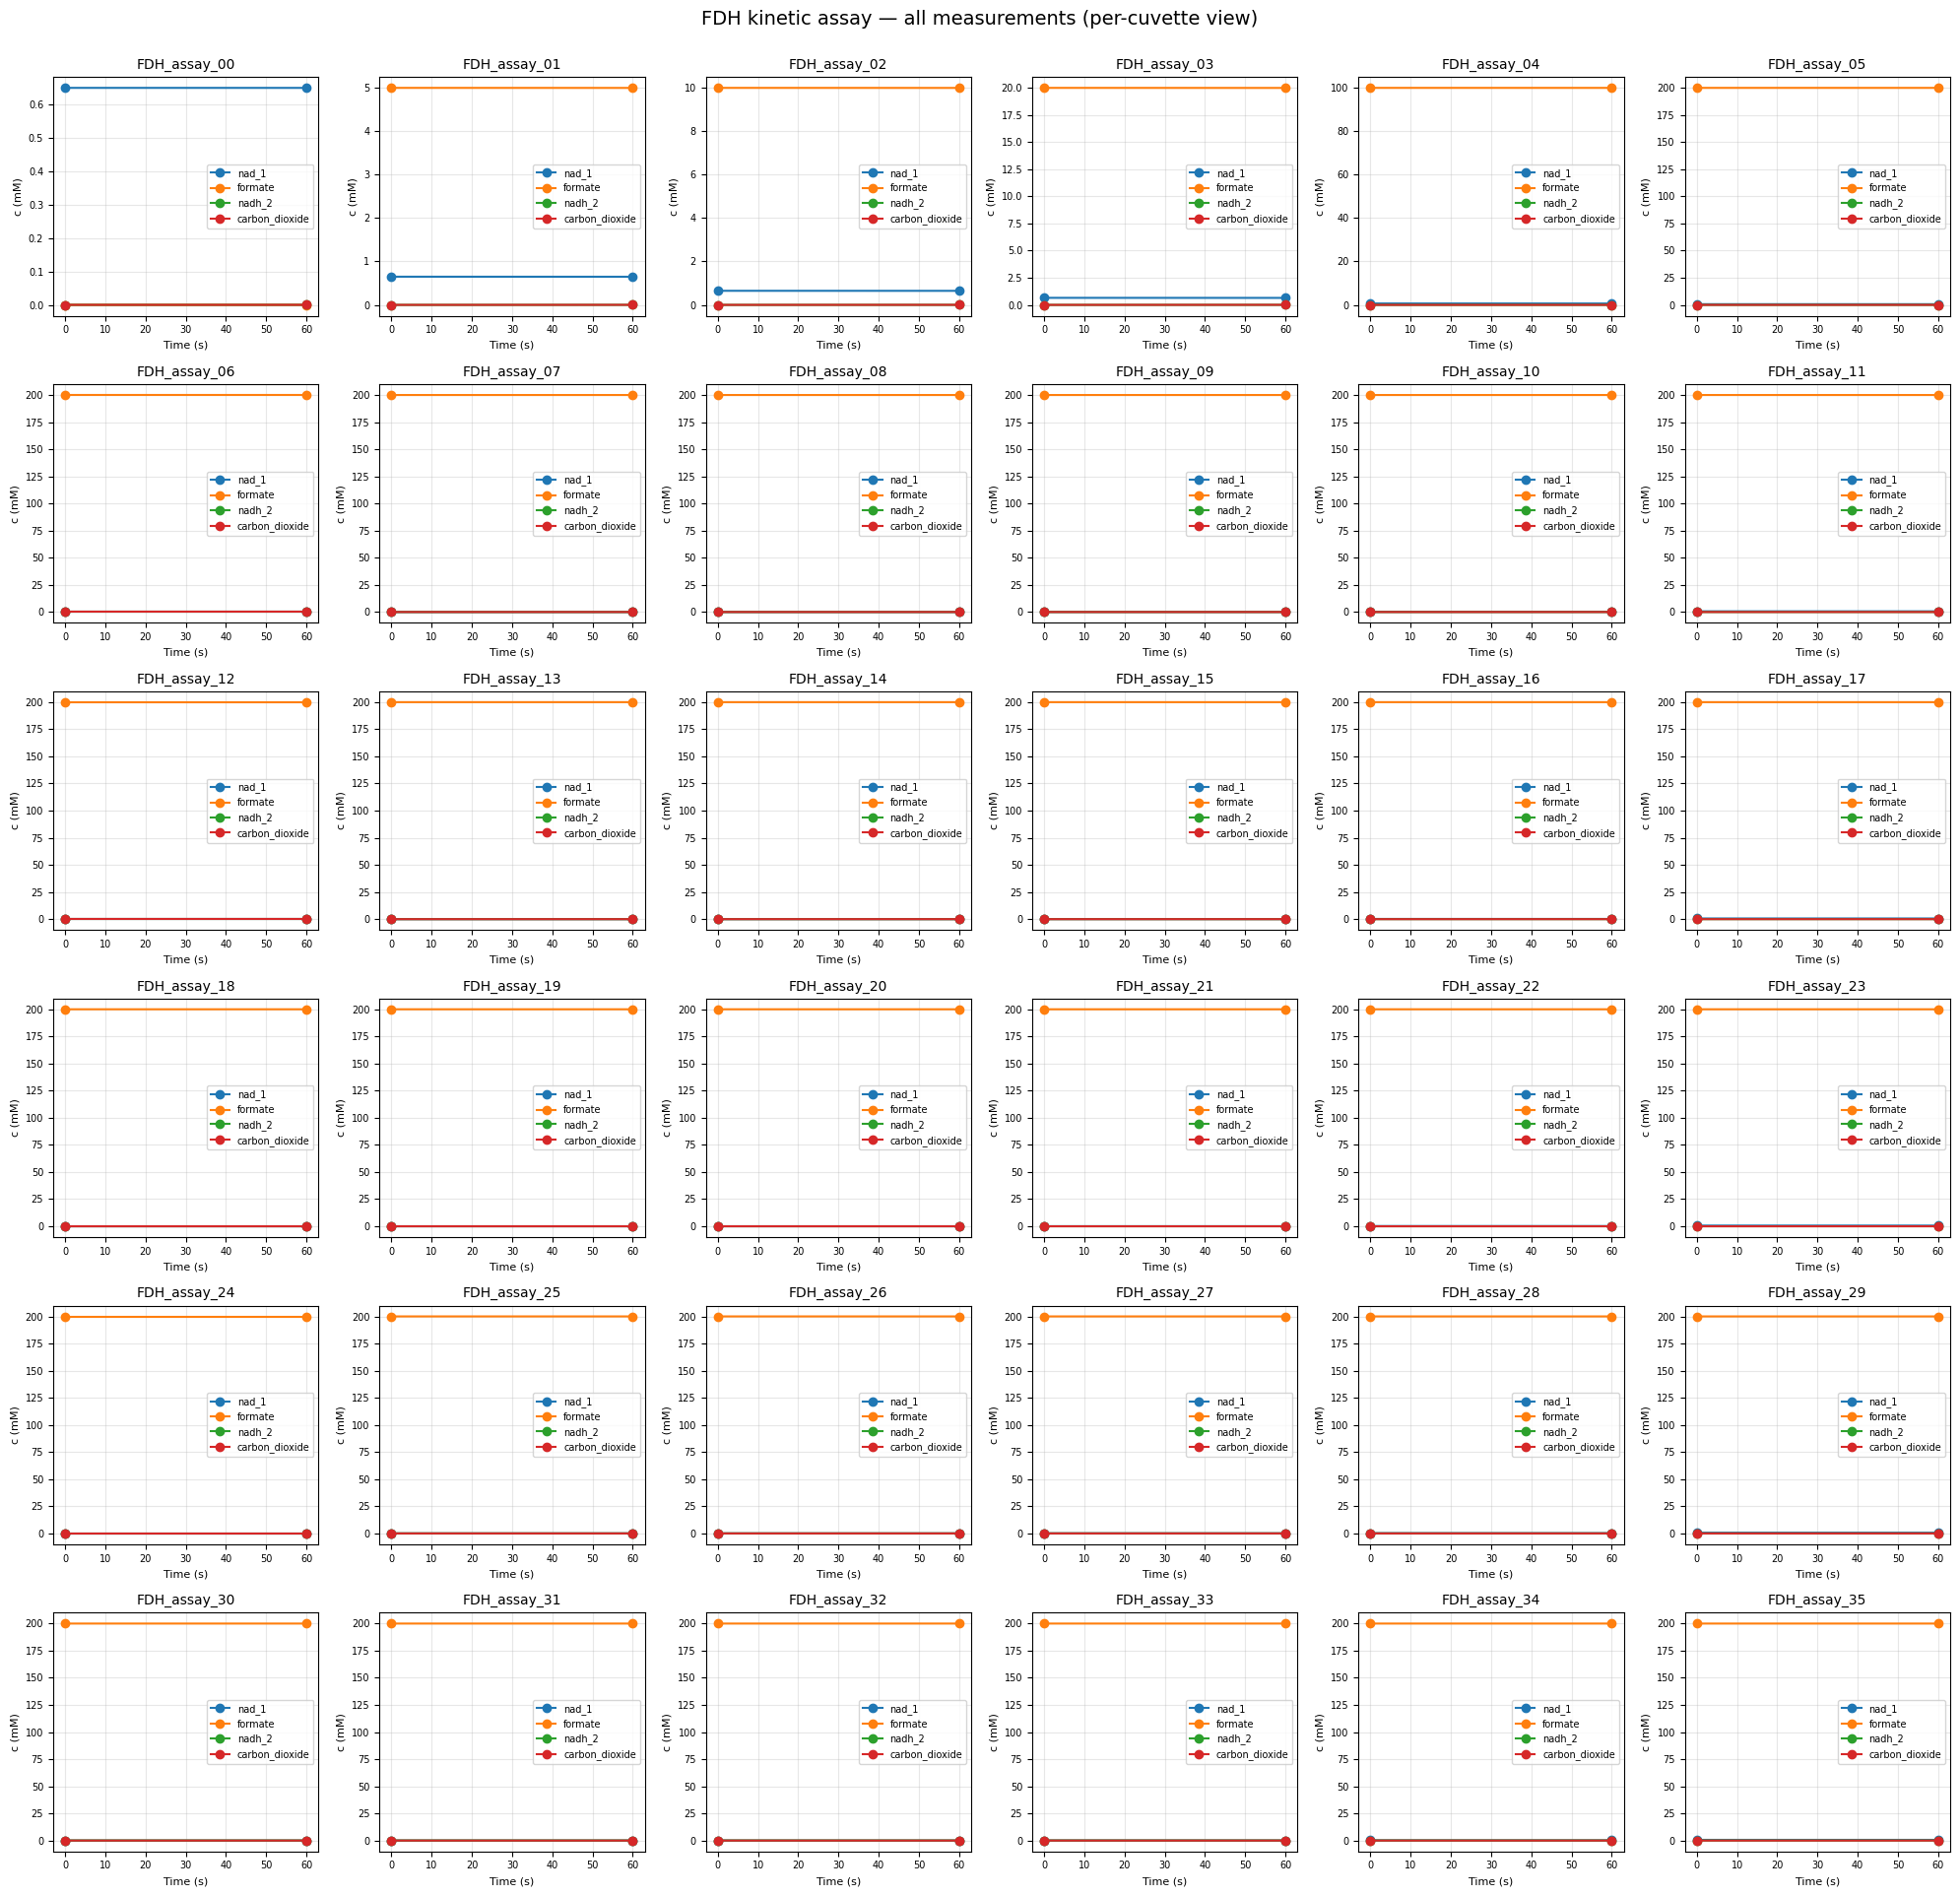

Plotted 36 measurements from the EnzymeML document.


In [9]:
# 6 x 6 grid – one subplot per measurement, all species overlaid
n = len(doc.measurements)
n_cols = 6
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.2 * n_rows))
axes = axes.flatten()

for idx, meas in enumerate(doc.measurements):
    ax = axes[idx]
    for sd in meas.species_data:
        if sd.data:
            ax.plot(sd.time, sd.data, marker="o", label=sd.species_id, linewidth=1.5)
    ax.set_title(meas.name, fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("c (mM)", fontsize=8)
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.suptitle("FDH kinetic assay — all measurements (per-cuvette view)", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()
print(f"Plotted {n} measurements from the EnzymeML document.")


<div style="border:2px solid #00d4ff; padding:15px; border-radius:10px; background-color:#1e1e1e; color:#eaeaea;">

In this step, we visualize all 36 enzyme measurements directly from the EnzymeML document to verify that the reaction data was stored and linked correctly. The plots help us confirm expected reaction behavior such as substrate consumption and product formation over time, while also helping detect unusual or incorrect measurements.

CS analogy:

> Similar to plotting processed datasets for validation, debugging, and anomaly detection before running downstream analytics or machine learning workflows.

</div>

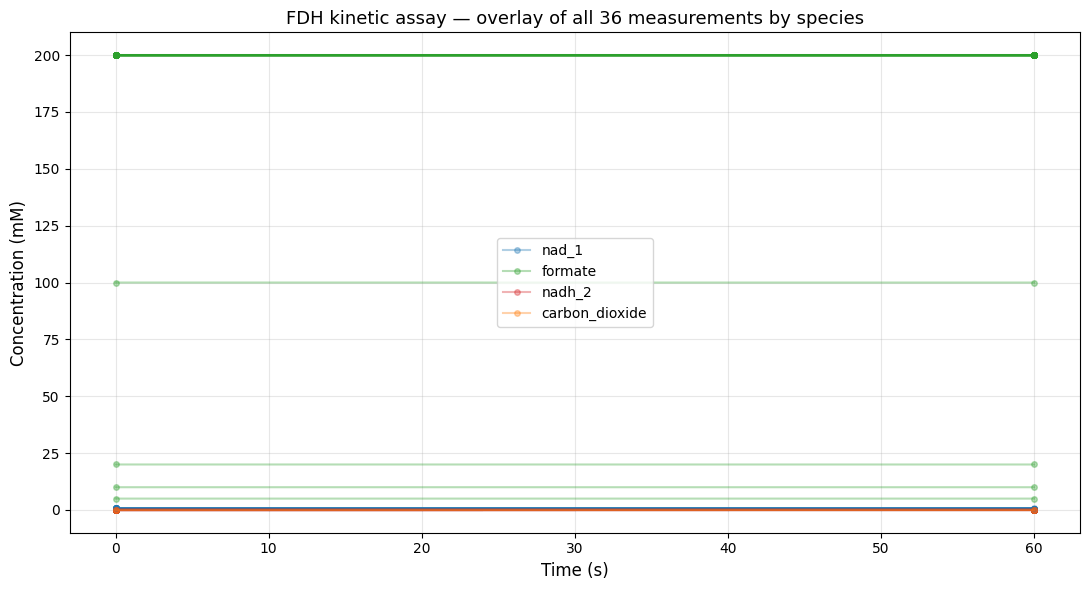

In [10]:
# All measurements overlaid, coloured by species
species_colors = {
    "nad_1":          "tab:blue",
    "formate":        "tab:green",
    "nadh_2":         "tab:red",
    "carbon_dioxide": "tab:orange",
}

fig, ax = plt.subplots(figsize=(11, 6))

seen = set()
for meas in doc.measurements:
    for sd in meas.species_data:
        if not sd.data:
            continue
        color = species_colors.get(sd.species_id, "gray")
        label = sd.species_id if sd.species_id not in seen else None
        seen.add(sd.species_id)
        ax.plot(sd.time, sd.data, color=color, alpha=0.35, marker="o", markersize=4, label=label)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Concentration (mM)", fontsize=12)
ax.set_title("FDH kinetic assay — overlay of all 36 measurements by species", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


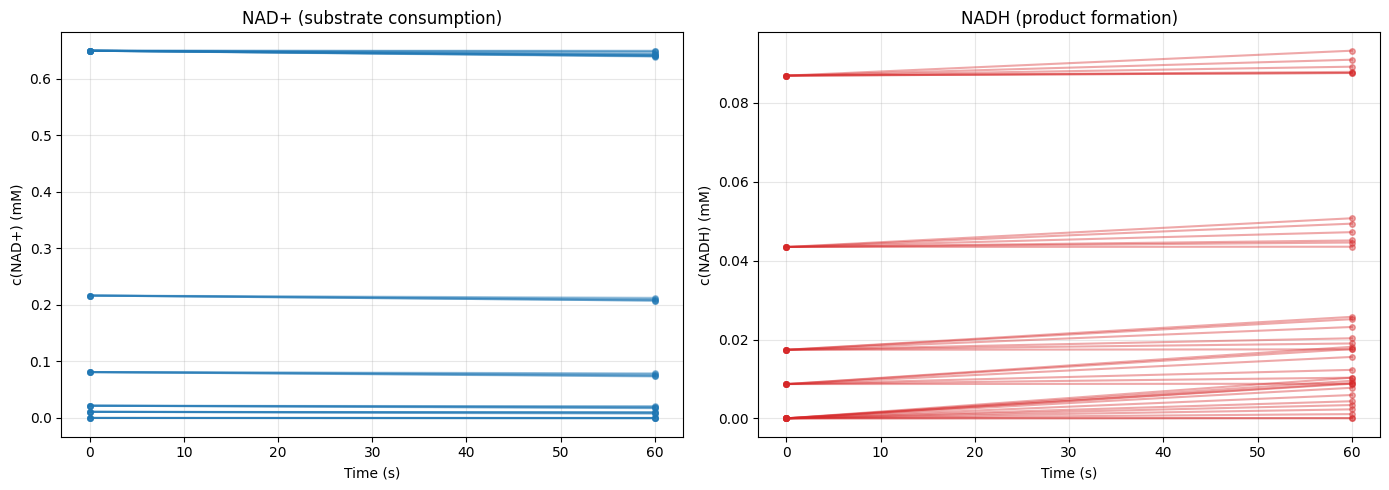

Concentration change over 60 s (from the EnzymeML document):
------------------------------------------------------------
  NAD+   mean = -0.004283 mM   range = [-0.010305, -0.000016]   std = 0.003335
  NADH   mean = +0.004283 mM   range = [+0.000016, +0.010305]   std = 0.003335
------------------------------------------------------------
Note: small changes are expected — these are *initial-rate* measurements in the linear (<10% conversion) regime.


In [11]:
# Focused view: NAD+ consumption vs NADH formation, plus delta statistics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

nad_changes  = []
nadh_changes = []

for meas in doc.measurements:
    for sd in meas.species_data:
        if not sd.data or len(sd.data) < 2:
            continue
        delta = sd.data[-1] - sd.data[0]
        if sd.species_id == "nad_1":
            ax1.plot(sd.time, sd.data, color="tab:blue", alpha=0.4, marker="o", markersize=4)
            nad_changes.append(delta)
        elif sd.species_id == "nadh_2":
            ax2.plot(sd.time, sd.data, color="tab:red", alpha=0.4, marker="o", markersize=4)
            nadh_changes.append(delta)

ax1.set(title="NAD+ (substrate consumption)", xlabel="Time (s)", ylabel="c(NAD+) (mM)")
ax2.set(title="NADH (product formation)",     xlabel="Time (s)", ylabel="c(NADH) (mM)")
for a in (ax1, ax2):
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Concentration change over 60 s (from the EnzymeML document):")
print("-" * 60)
if nad_changes:
    arr = np.array(nad_changes)
    print(f"  NAD+   mean = {arr.mean():+.6f} mM   "
          f"range = [{arr.min():+.6f}, {arr.max():+.6f}]   std = {arr.std():.6f}")
if nadh_changes:
    arr = np.array(nadh_changes)
    print(f"  NADH   mean = {arr.mean():+.6f} mM   "
          f"range = [{arr.min():+.6f}, {arr.max():+.6f}]   std = {arr.std():.6f}")
print("-" * 60)
print("Note: small changes are expected — these are *initial-rate* measurements "
      "in the linear (<10% conversion) regime.")


<div style="border:2px solid #00d4ff; padding:15px; border-radius:10px; background-color:#1e1e1e; color:#eaeaea;">

In this step, all enzyme measurements are plotted together to compare how molecule concentrations change over time across all experiments. The graphs confirm the expected reaction behavior: NAD⁺ decreases slightly (substrate consumption) while NADH increases slightly (product formation), showing that the reaction data inside the EnzymeML document is consistent and correctly structured.

The statistical summary also verifies that only small concentration changes occurred during the 60-second window, which is expected for reliable initial-rate measurements in the linear reaction range.

CS analogy:

> Similar to visualizing and validating trends in a processed dataset to confirm correct system behavior and detect anomalies before downstream modeling or analytics.

</div>

[Back to top](#top)

---

<a id="sec-outlook"></a>

# Conclusion & Outlook

## Key learning outcomes

In this module you have:

1. **Connected FAIR theory to practice** — by mapping each FAIR letter to a concrete artefact in an EnzymeML document (identifiers, ontology links, metadata, units, licence).
2. **Understood how STRENDA and EnzymeML relate** — STRENDA defines *what* should be reported; EnzymeML provides a *machine-readable* structure for it.
3. **Built an EnzymeML document programmatically** using PyEnzyme:
   - fetched the enzyme from UniProt and the reaction (with all participating species) from Rhea,
   - mapped a tabular dataset onto EnzymeML `Measurement` objects,
   - serialised the result to JSON in `Data/enzymeml/`.
4. **Got to know an alternative GUI workflow** with the EnzymeML Suite, knowing that both routes produce the *same* kind of file.
5. **Quality-checked** the resulting document by visualising the time courses directly from the EnzymeML object.

<div style="border:2px solid #00d4ff; padding:15px; border-radius:10px; background-color:#1e1e1e; color:#eaeaea;">

In this module, we learned how FAIR and STRENDA principles are applied in real enzyme experiments by converting processed experimental data into a structured, machine-readable EnzymeML document using PyEnzyme. We integrated biological databases like UniProt and Rhea, mapped experimental measurements into standardized EnzymeML objects, explored both coding and GUI-based workflows, and finally validated the generated EnzymeML document through visualization and quality checks.

> Similar to transforming raw experimental CSV data into a validated, standardized JSON-based data model that can be reused across analytics, simulation, and machine learning systems.

</div>

You are now ready to proceed to **KIN-01a: Kinetic Modeling**, which will:

- load `Data/enzymeml/FDH_kinetics_latest.json`,
- fit Michaelis–Menten parameters (including the NADH product-inhibition term),
- compare linearisation methods with non-linear regression,
- write the fitted kinetic parameters back into the EnzymeML document.

Beyond this teaching series, the same document can be:

- uploaded to **STRENDA DB** for community submission,
- imported into **COPASI** or **PySCeS** via SBML for systems-biology modeling,
- archived on **Zenodo** with a DOI for citation,
- used as a training example for ML/AI workflows on enzyme-kinetic data.

## Reflective questions

Before moving on, consider:

1. Which of the four FAIR letters does a plain CSV with a free-text README *not* fulfil — and how does EnzymeML close that gap?
2. Why is it useful that PyEnzyme fetches molecules and reactions from Rhea / ChEBI / UniProt rather than letting you type IDs by hand?
3. Sometimes raw analytical data is of high volume. Which data is more important to keep, raw analytical data or processed data such as the one saved in an EnzymeML document? 
4. Why is the processed data in terms of concentrations important to be kept? Isn't the model and the determined kinetic parameters what matter?
5. What benefits does a standard data exchange format such as EnzymeML provide?


<a id="sec-references"></a>

# References & Resources

### EnzymeML and tooling

1. **EnzymeML homepage** — <https://enzymeml.org/>
   Overview of the data model, motivation and current specification (v2).
2. **EnzymeML v2 specification** — <https://enzymeml.org/versions/v2/>
   Full data-model reference (Protein, SmallMolecule, Reaction, Measurement, …).
3. **PyEnzyme (Python API)** — <https://github.com/EnzymeML/PyEnzyme>
   Source code, examples and installation instructions.
4. **PyEnzyme documentation** — <https://pyenzyme.vercel.app/>
   API reference and tutorials.
5. **EnzymeML Suite (desktop GUI)** — <https://github.com/EnzymeML/enzymeml-suite>
   Cross-platform graphical front-end for building EnzymeML documents.
   - Installers: <https://github.com/EnzymeML/enzymeml-suite/releases>

### Standards and databases referenced by EnzymeML

6. **STRENDA homepage** (Beilstein-Institut) — <https://www.beilstein-institut.de/en/projects/strenda/>
7. **STRENDA Biocatalysis guidelines** — <https://www.beilstein-institut.de/en/projects/strenda/strenda-bio/>
8. **STRENDA DB** — <https://www.beilstein-strenda-db.org/>
9. **Rhea reaction database** — <https://www.rhea-db.org/>
   FDH reaction used here: [RHEA:15985](https://www.rhea-db.org/rhea/15985).
10. **UniProt** — <https://www.uniprot.org/>
    FDH1 from *Candida boidinii*: [O13437](https://www.uniprot.org/uniprotkb/O13437/entry).
11. **ChEBI** — <https://www.ebi.ac.uk/chebi/>
12. **PubChem** — <https://pubchem.ncbi.nlm.nih.gov/>

### FAIR principles

13. Wilkinson, M. D. *et al.* (2016). *The FAIR Guiding Principles for scientific data management and stewardship.* **Sci. Data** 3, 160018. <https://doi.org/10.1038/sdata.2016.18>
14. **GO FAIR** — <https://www.go-fair.org/fair-principles/>

[Back to top](#top)


<a id="sec-ack"></a>

# Acknowledgments

This module was developed as part of the **Teach Open Biocatalysis** initiative — a collaborative effort by **Max Häußler** (University of Stuttgart), **Niklas-Maximilian Epping** (Hamburg University of Technology) and **Amalie Vang Høst** (University of Bielefeld) — to provide accessible, standards-compliant educational materials for enzyme kinetics, research data management and kinetic modeling.

The research-data-management content of this notebook builds directly on the work of the **group of Prof. Jürgen Pleiss** at the University of Stuttgart, whose ongoing development of the **EnzymeML** community standard, the **PyEnzyme** library and the **EnzymeML Suite** desktop GUI provides the entire infrastructure used here. Special thanks to **Max Häußler**, **Jan Range** and **Torsten Giess** for their work on EnzymeML and the surrounding FAIR-data tooling that makes reproducible, machine-readable enzyme-kinetics workflows possible.

We further acknowledge the **Beilstein-Institut** and the wider **STRENDA / STRENDA-Biocatalysis** community for the underlying reporting standards that EnzymeML implements, and the maintainers of **Rhea**, **UniProt**, **ChEBI** and **PubChem** for providing the open, ontology-linked metadata that PyEnzyme fetches at runtime.

**License:** This educational material is available under an open-source license. Please cite this module when using it for teaching or research purposes.

[Back to top](#top)
